<a href="https://colab.research.google.com/github/MajorTomTom792/miRNA-analysis/blob/main/original.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install cutadapt
!pip install Biopython
!pip install pydeseq2
!pip install pysam
from sklearn.preprocessing import MinMaxScaler
from collections import defaultdict
from typing import Counter
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference
from formulaic_contrasts import FormulaicContrasts
from functools import partial
from Bio import SeqIO
import numpy as np
import subprocess
import os
import random
import shutil
import math
import pysam
import pickle as pkl
import pandas as pd
import scipy
import sklearn
import matplotlib.pyplot as plt
import statistics
dictionaries = {'A': 0, 'T': 1, 'G': 2, 'C': 3, 'N': 4}
start = 'SRR'
adapter = 'TGGAATTCTCGGGTGCCAAGGAACTCCAG'
#adapter = 'AGATCGGAAGAGCACACGTCTGAACTCC'
mature_fa = '/content/mature.fa'
hairpin_fa = '/content/hairpin.fa'
mmu_mature1 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/Alignment/mmu_mature.fa'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.1/281.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.1/106.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.4/132.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 49.1 MB/s eta 0:00:00

In [ ]:
!wget https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz
!tar xvfz mmseqs-linux-avx2.tar.gz
!./mmseqs/bin/mmseqs easy-cluster {input.fasta} out tmp \
    --min-seq-id 1 \
    -c 1 \
    --cov-mode 0

# id 100%, length equal = 100%

In [ ]:
def combining(files1,files2,files3, types):
  lists1 = []
  lists2 = []
  lists3 = []
  lists1 = files_dictionary(files1, dictionaries, 'SRR', 'fastq')
  lists2 = files_dictionary(files2, dictionaries, 'SRR', 'fastq')
  lists3 = files_dictionary(files3, dictionaries, 'SRR', 'fastq')
  lists1 = lists1 + lists2 + lists3
  name = types + 'trimmed'
  with open(name, 'w') as f:
    for items in lists1:
      if items.startswith('SRR'):
        f.write('>' + items + '\n')
      else:
        f.write(items + '\n')

In [ ]:
#files1 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/trimmed_control1.fastq'
#files2 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/trimmed_control2.fastq'
#files3 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/trimmed_control3.fastq'
#files4 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/trimmed_High1.fastq'
#files5 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/trimmed_High2.fastq'
#files6 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/trimmed_High3.fastq'
#combining(files1, files2, files3, 'Control')
#combining(files4, files5, files6, 'High')

In [ ]:
def files_dictionary(files, dictionary, startingLetter, fileFormat):
  from Bio import SeqIO
  new_list = []
  for record in SeqIO.parse(files, fileFormat):  # Changed "fasta" to "fastq"
      if record.id.startswith(startingLetter):  # mouse
          #dictionary[str(record.id)] = 0
          new_list.append(str(record.id))
          new_list.append(str(record.seq))
  return new_list

#download files via code
def download_files(filess):
  if os.path.exists(filess):
      files.download(filess)

#moves files to a directory
def moving(filez, directory):
  source_file = filez
  destination_dir = directory
  shutil.move(source_file, destination_dir)

def trimmer(input_file, output_file, adapter):
  #!apt install fastqc -y
  #!fastqc {input_file} -o input_dic_name/
  !cutadapt --fasta -b {adapter} --trim-n -O 10 -m 18 -M 25 -n 1 -o {output_file} {input_file}
  X = output_file
def alignprep(inputfile, outputfile):
  counts = defaultdict(int)
  for record in SeqIO.parse(inputfile, 'fasta'):
    counts[str(record.seq)] += 1

  with open(outputfile, 'w') as f:
    for i, (seq, num) in enumerate(counts.items()):
      f.write('>Seq' + str(i+1) + 'x' + str(num) + '\n' + seq + '\n')
  x = '/content/' + outputfile
  return x


def alignprep(inputfile, outputfile):
  counts = defaultdict(int)
  for record in SeqIO.parse(inputfile, 'fastq'):
    counts[str(record.seq)] += 1
  for key, items in counts.items():
    if items <= 20:
      del counts[key]
  with open(outputfile, 'w') as f:
    for i, (seq, num) in enumerate(counts.items()):
      f.write('>' + 'Seq' + str(i+1) + 'x' + str(num) + '\n' + seq + '\n')
  x = '/content/' + outputfile
  return x

def bowtie(input_file, aligner, output_file):
  '''
  !apt update
  !apt install -y bowtie
  !bowtie --version
  !bowtie-build {aligner} mmu_mature
  inputs = input('1st or more bowtie: ')
  if inputs == '1':
    !bowtie -f -v 2 -k 1 -l 7 mmu_mature {input_file} > {output_file}
  else:
    !bowtie -f -v 3 -k 1 -l 7 mmu_mature {input_file} > {output_file}
  x = '/content/' + output_file
'''
  !apt update
  !apt install -y bowtie2
  !bowtie2 --version
  !bowtie2-build {aligner} mmu_mature
  !bowtie2 -f -x mmu_mature -U {input_file} -S {output_file} -L 7 -N 1 -k 1 --end-to-end
  x = '/content/' + output_file
  return x


def postBowtie2(inputFile):
  test = []
  dictionary = {}
  string = 0
  samfile = pysam.AlignmentFile(inputFile, 'r')
  for read in samfile.fetch():
    if not read.is_unmapped:
      string = int(str(read.qname).split('x')[-1])
      test.append(string)
      if str(read.reference_name) in dictionary:
        dictionary[str(read.reference_name)] += string
      else:
        dictionary[str(read.reference_name)] = string
  return [dictionary, test]

def bootstrapCSV(types, dicts, number_of_bootstraps, all_miRNA_names, metadatas):
  bootstrapSample= {}
  metadata = {}
  if types == 'High':
    metadata = metadatas

  for z in range(1, int(number_of_bootstraps) + 1):
    sample_name = f'{types}{z}'
    metadata[sample_name] = types
    mmu_names = {miRNA: 0 for miRNA in all_miRNA_names}
    total_reads_in_original_sample = sum(dicts.values())
    #bootstrapped_total_reads = round(total_reads_in_original_sample ** 0.75)
    bootstrapped_total_reads = 300000
    miRNAs_dicts = list(dicts.keys())
    weights = list(dicts.values())
    item_num = int(len(weights))

    randomSelection = random.choices(miRNAs_dicts, weights=weights, k=bootstrapped_total_reads)
    counts_from_selection = Counter(randomSelection)
    for key, count in counts_from_selection.items():
        if key in mmu_names:
            mmu_names[key] = count
    if z == 1 and types == 'Control':
      csv = pd.DataFrame(index=all_miRNA_names)
      csv[sample_name] = pd.Series(mmu_names)
      csv.to_csv('/content/read_files.csv', index_label= 'miRNA Names',index = True)
    else:
      csv = pd.read_csv('/content/read_files.csv', index_col=0)
      csv[sample_name] = pd.Series(mmu_names)
      csv.to_csv('/content/read_files.csv', index = True)

  if types == 'High':
    csv = pd.DataFrame(index=metadata.keys())
    csv['Types'] = pd.Series(metadata)
    csv.to_csv('metadata.csv', index_label='Sample Names', index = True)

  return metadata


def Deseq2(countsFile, metadata_file):
  counts_df = pd.read_csv(countsFile, index_col=0)
  metadata = pd.read_csv(metadata_file, index_col=0)
  #transpose
  counts_df = counts_df.T

  common_samples = counts_df.index.intersection(metadata.index)
  print(common_samples)
  counts_df = counts_df.loc[common_samples]
  metadata = metadata.loc[common_samples]

  inference = DefaultInference(n_cpus=8)

  dds = DeseqDataSet(
      counts=counts_df,
      metadata=metadata,
      design="~Types",
      inference=inference
  )

  dds.var_names_make_unique()

  dds.deseq2()
  stat_res = DeseqStats(dds, ['Types', 'High', 'Control'], inference=inference)
  stat_res.summary()
  p_thresh = 0.05
  fc_thresh = 0.3

  results_df = stat_res.results_df
  #print(len(list(results_df)))

  results = results_df.sort_values(by='padj', ascending=True)#[results_df['padj'] < 0.05].sort_values(by='padj', ascending=True)
  results = results[abs(results['log2FoldChange']) > fc_thresh ].sort_values(by='log2FoldChange', ascending=True)


  up = (results_df['padj'] < p_thresh) & (results_df['log2FoldChange'] >= fc_thresh)
  down = (results_df['padj'] < p_thresh) & (results_df['log2FoldChange'] <= -fc_thresh)
  outside = (results_df['padj'] > p_thresh)
  plot_object = plt.scatter(
      (results_df['log2FoldChange'])[up],
      (-np.log10(results_df['padj']))[up],
      label='Upregulated',
      s=10,
      color = 'red'
  )
  plot_object = plt.scatter(
      (results_df['log2FoldChange'])[down],
      (-np.log10(results_df['padj']))[down],
      label='Downregulated',
      s=10,
      color = 'blue'
  )
  plt.scatter(
      (results_df['log2FoldChange'])[outside],
      (-np.log10(results_df['padj']))[outside],
      label='No cutoff',
      s=10,
      color = 'Gray')

  plt.axhline(y=-np.log10(p_thresh), color='green', linestyle='--', linewidth=1)
  plt.axvline(x=fc_thresh, color='green', linestyle='--', linewidth=1)
  plt.axvline(x=-fc_thresh, color='green', linestyle='--', linewidth=1)

  plt.xlabel('log2 Fold Change')
  plt.ylabel('-log10 adjusted p-value')
  plt.title('Gene expression')
  plt.legend()
  plt.show()


  results_df = pd.DataFrame(results)
  #results_df = results_df[(results_df['log2FoldChange'] > 0.5 | (results_df['log2FoldChange'] < -0.5))]
  results_df.to_csv('stats_res.csv', index=True)

Index(['Control1', 'Control2', 'Control3', 'Control4', 'Control5', 'Control6',
       'Control7', 'Control8', 'Control9', 'Control10', 'Control11',
       'Control12', 'Control13', 'Control14', 'Control15', 'Control16',
       'Control17', 'Control18', 'Control19', 'Control20', 'Control21',
       'Control22', 'Control23', 'Control24', 'Control25', 'Control26',
       'Control27', 'Control28', 'Control29', 'Control30', 'Control31',
       'Control32', 'Control33', 'Control34', 'Control35', 'Control36',
       'Control37', 'Control38', 'Control39', 'Control40', 'Control41',
       'Control42', 'Control43', 'Control44', 'Control45', 'Control46',
       'Control47', 'Control48', 'Control49', 'Control50', 'High1', 'High2',
       'High3', 'High4', 'High5', 'High6', 'High7', 'High8', 'High9', 'High10',
       'High11', 'High12', 'High13', 'High14', 'High15', 'High16', 'High17',
       'High18', 'High19', 'High20', 'High21', 'High22', 'High23', 'High24',
       'High25', 'High26', 'High27', 

Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 1.61 seconds.

Fitting dispersion trend curve...
/usr/local/lib/python3.12/dist-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 4.69 seconds.

Fitting LFCs...
... done in 2.28 seconds.

Calculating cook's distance...
... done in 0.08 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.63 seconds.



Log2 fold change & Wald test p-value: Types High vs Control
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
miRNA Names                                                                 
mmu-miR-6933-5p    0.086878        0.444096  1.492237  0.297604  0.766005   
mmu-miR-6392-5p    0.305791        0.444098  0.501877  0.884874  0.376224   
mmu-miR-6946-3p    0.088739        0.097850  1.490406  0.065653  0.947654   
mmu-miR-7032-3p    0.149891       -0.248396  0.881177 -0.281891  0.778027   
mmu-miR-7231-5p    0.384906        0.444098  0.501732  0.885130  0.376087   
...                     ...             ...       ...       ...       ...   
mmu-miR-3088-3p    0.077801        0.270973  1.487500  0.182167  0.855452   
mmu-miR-1a-3p     12.404183        0.341874  0.089772  3.808244  0.000140   
mmu-miR-7661-3p    0.320415       -0.767766  0.588759 -1.304041  0.192220   
mmu-miR-3112-3p    0.000000             NaN       NaN       NaN       NaN   
mmu-miR-12205-5p

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


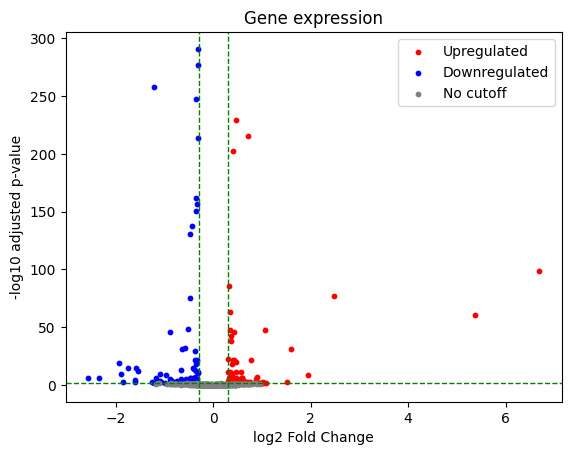

In [ ]:
'''
def combine(input_file):
  lists = []
  for records in SeqIO.parse(input_file, 'fastq'):
    lists.append(str(records.id))
    lists.append(str(records.seq))
  return lists
#XRaw files combine
files1 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/CON/SRR12879947.fastq'
files2 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/CON/SRR12879948.fastq'
files3 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/CON/SRR12879949.fastq'
files4 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/HIGH/SRR12879950.fastq'
files5 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/HIGH/SRR12879951.fastq'
files6 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/HIGH/SRR12879952.fastq'
SeqIO.convert(files1, 'fastq', 'control1.fasta', 'fasta')
trimmer('/content/control1.fasta', 'trimmed_control1.fasta', adapter)

def combine(input_file):
  lists = []
  for records in SeqIO.parse(input_file, 'fastq'):
    lists.append(str(records.id))
    lists.append(str(records.seq))
  return lists

#postBowtie2('/content/bowtie1.sam')
preC=postBowtie2('/content/bowtieControlPlastic.sam')[0]
preH=postBowtie2('/content/bowtieHigh.sam')[0]
combined_list = list(set(list(preC.keys()) + list(preH.keys())))
x = bootstrapCSV('High', preH, 50, combined_list, bootstrapCSV('Control', preC, 50, combined_list, 'Hi'))
'''

#bowtie(alignprep('/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/trimmed_control1.fastq', 'prep1'), mmu_mature1, 'bowtie1.sam')
#bowtie(alignprep('/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/trimmed_control2.fastq', 'prep1'), mmu_mature1, 'bowtie2.sam')
#bowtie(alignprep('/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/trimmed_control3.fastq', 'prep1'), mmu_mature1, 'bowtie3.sam')
#bowtie(alignprep('/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/trimmed_High1.fastq', 'prep1'), mmu_mature1, 'bowtie4.sam')
#bowtie(alignprep('/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/trimmed_High2.fastq', 'prep1'), mmu_mature1, 'bowtie5.sam')
#bowtie(alignprep('/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/trimmed_High3.fastq', 'prep1'), mmu_mature1, 'bowtie6.sam')

Deseq2('/content/read_files50Plastic.csv', '/content/metadata50Plastic.csv')

In [ ]:
'''
df = pd.read_csv('/content/stats_res.csv', index_col=0)
df = df[(df['baseMean'] > 100) & (abs(df['log2FoldChange']) > 0.3)]
df.to_csv('test1.csv', index=True)
'''
df = pd.read_csv('/content/stats_res50Plastic.csv', index_col=0)
df1 = df.sort_values(by='log2FoldChange', ascending=True)
df2 = df.sort_values(by='log2FoldChange', ascending=False)
df1 = df1[(df1['baseMean'] > 100)]
df2 = df2[(df2['baseMean'] > 100)]
df1 = df1.head(5)
df2 = df2.head(5)
df = pd.concat([df1,df2], axis=0)
df.to_csv('test.csv', index=True)

df = pd.read_csv('/content/test.csv', index_col=0)
rank = list(range(1,11))
dictionary = {}
dictionaryold = {}

lists = list(df['log2FoldChange'])
#oldLists = list(df['log2FoldChange'])

for i in range(len(lists)):
  if lists[i] < 0:
    lists[i] = abs(lists[i])


oldList = sorted(lists, reverse=True)

for i in range(len(oldList)):
  dictionary[oldList[i]] = rank[i]

oldList = list(df['log2FoldChange'])
for items in oldList:
  for key, value in dictionary.items():
    if abs(items) == key:
      dictionaryold[items] = value

df['Rank'] = dictionaryold.values()
df = df.sort_values(by='Rank', ascending=True)
df.to_csv('test.csv', index=True)
print(dictionaryold)


{-0.5096616438554085: 5, -0.4788139092827685: 6, -0.4694614185989638: 8, -0.4385372893046713: 9, -0.4160712264195814: 10, 2.023548519282031: 1, 1.374426173452909: 2, 0.7059422018295848: 3, 0.5186187808737658: 4, 0.4716549040596152: 7}


Index(['Control1', 'Control2', 'Control3', 'Control4', 'Control5', 'Control6',
       'Control7', 'Control8', 'Control9', 'Control10', 'Control11',
       'Control12', 'Control13', 'Control14', 'Control15', 'Control16',
       'Control17', 'Control18', 'Control19', 'Control20', 'Control21',
       'Control22', 'Control23', 'Control24', 'Control25', 'Control26',
       'Control27', 'Control28', 'Control29', 'Control30', 'Control31',
       'Control32', 'Control33', 'Control34', 'Control35', 'Control36',
       'Control37', 'Control38', 'Control39', 'Control40', 'Control41',
       'Control42', 'Control43', 'Control44', 'Control45', 'Control46',
       'Control47', 'Control48', 'Control49', 'Control50', 'High1', 'High2',
       'High3', 'High4', 'High5', 'High6', 'High7', 'High8', 'High9', 'High10',
       'High11', 'High12', 'High13', 'High14', 'High15', 'High16', 'High17',
       'High18', 'High19', 'High20', 'High21', 'High22', 'High23', 'High24',
       'High25', 'High26', 'High27', 

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.05 seconds.

Fitting dispersion trend curve...
/usr/local/lib/python3.12/dist-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.05 seconds.

Fitting LFCs...
... done in 0.03 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.03 seconds.

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Log2 fold change & Wald test p-value: Types High vs Control
                      baseMean  log2FoldChange     lfcSE        stat  \
Types of Editing                                                       
A-T                3395.520210       -0.396677  0.007487  -52.982855   
A-G                 808.484569        0.061572  0.011120    5.537271   
A-C                 386.687794        1.907407  0.018753  101.714761   
T-A                3461.585621       -0.039845  0.007142   -5.578980   
T-G               17486.331337        1.577978  0.005857  269.398538   
T-C                 732.366145       -0.059044  0.011450   -5.156590   
G-A                1492.320545       -0.121372  0.009492  -12.787281   
G-T                4659.913997        2.861600  0.008837  323.805523   
G-C                  84.704850       -0.109516  0.031781   -3.445948   
C-A                2356.962919       -0.083868  0.007751  -10.819724   
C-T                2212.506221       -0.087058  0.007917  -10.996261   
C-G 

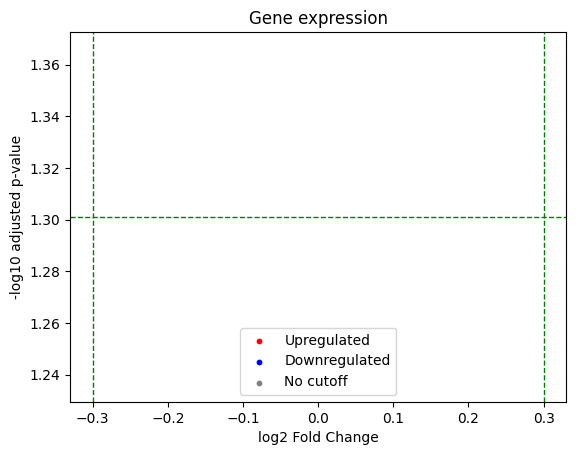

In [ ]:
'''
#files1 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/SRR31307967.fasta'
files2 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/SRR31307968.fasta'
files3 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/SRR31307969.fasta'
#files4 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/SRR31307970.fasta'
#files5 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/SRR31307971.fasta'
files6 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/SRR31307972.fasta'

#trimmer(files1, 'trimmedCon67.fasta', adapter)
trimmer(files2, 'trimmedMigraine68.fasta', adapter)
trimmer(files3, 'trimmedMigraine69.fasta', adapter)
#trimmer(files4, 'trimmedCon70.fasta', adapter)
#trimmer(files5, 'trimmedCon71.fasta', adapter)
trimmer(files6, 'trimmedMigraine72.fasta', adapter)

#conList = []
migraineList = []
def combine(input_file):
  lists = []
  for records in SeqIO.parse(input_file, 'fasta'):
    lists.append(str(records.id))
    lists.append(str(records.seq))
  return lists

conList = combine('/content/trimmedCon67.fasta')
conList += combine('/content/trimmedCon70.fasta')
conList += combine('/content/trimmedCon71.fasta')
with open('controlMigraine.fasta', 'w') as f:
  for items in conList:
    if 'SRR' in items:
      f.write('>' + items + '\n')
    else:
      f.write(items + '\n')

migraineList = combine('/content/trimmedMigraine68.fasta')
migraineList += combine('/content/trimmedMigraine69.fasta')
migraineList += combine(f'/content/trimmedMigraine72.fasta')
with open('Migraine.fasta', 'w') as f:
  for items in migraineList:
    if 'SRR' in items:
      f.write('>' + items + '\n')
    else:
      f.write(items + '\n')

bowtie(alignprep('/content/controlMigraine.fasta', 'prepControl1'), mmu_mature1, 'bowtieControl.sam')
bowtie(alignprep('/content/Migraine.fasta', 'prepControl1'), mmu_mature1, 'bowtieMigraine.sam')

def postBowtie2(inputFile):
  dictionary = {}
  string = 0
  samfile = pysam.AlignmentFile(inputFile, 'r')
  for read in samfile.fetch():
    if not read.is_unmapped:
      string = int(str(read.qname).split('x')[-1])
      if str(read.reference_name) in dictionary:
        dictionary[str(read.reference_name)] += string
      else:
        dictionary[str(read.reference_name)] = string
  return dictionary

preC=postBowtie2('/content/bowtieControl.sam')
preH=postBowtie2('/content/bowtieMigraine.sam')
print(sum(preC[1]))
print(sum(preH[1]))

preC = preC[0]
preH = preH[0]
combined_list = list(set(list(preC.keys()) + list(preH.keys())))
x = bootstrapCSV('High', preH, 50, combined_list, bootstrapCSV('Control', preC, 50, combined_list, 'Hi'))


#preC = preCSV('/content/bowtieControl')
#preH = preCSV('/content/bowtieMigraine')
#combined_list = list(set(list(preC.keys()) + list(preH.keys())))
#x = bootstrapCSV('High', preH, 100, combined_list, bootstrapCSV('Control', preC, 100, combined_list, 'Hi'))

counts_df = pd.read_csv('/content/read_files.csv', index_col=0)
metadata = pd.read_csv('/content/metadata.csv', index_col=0)
#transpose
counts_df = counts_df.T

common_samples = counts_df.index.intersection(metadata.index)

counts_df = counts_df.loc[common_samples]
metadata = metadata.loc[common_samples]

inference = DefaultInference(n_cpus=8)

dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata,
    design="~Types",
    inference=inference
)

dds.deseq2()
stat_res = DeseqStats(dds, ['Types', 'Control', 'High'], inference=inference)
stat_res.summary()

results_df = stat_res.results_df
results = results_df[results_df["padj"] < 0.05].sort_values(by='padj', ascending=True)

plot_object = plt.scatter(
    results_df["log2FoldChange"],
    -np.log10(results_df["padj"]),
    s=10
)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 adjusted p-value")
plt.show()




results_df = pd.DataFrame(results)
#results_df = results_df[(results_df['log2FoldChange'] > 0.5 | (results_df['log2FoldChange'] < -0.5))]
results_df.to_csv('stats_res.csv', index=True)


def error_sorter(inputFile, alignFile):
  inputs = pd.read_csv(inputFile, index_col=0)
  statAlign = pd.read_csv(alignFile, index_col=0)
  input_index = list(inputs.index)
  align_index = list(statAlign.index)
  note = []
  for items in input_index:
    if items not in align_index:
      note.append(items)
  inputs = inputs.drop(index=note)
  inputs.to_csv(input('What name: '), index=True)

error_sorter('/content/stats_resMigraineNucleotide.csv', '/content/test.csv')
'''

#bowtie(alignprep('/content/trimmedCon67.fasta', 'prep1'), mmu_mature1, 'bowtie67.sam')
#bowtie(alignprep('/content/trimmedMigraine68.fasta', 'prep1'), mmu_mature1, 'bowtie68.sam')
#bowtie(alignprep('/content/trimmedMigraine69.fasta', 'prep1'), mmu_mature1, 'bowtie69.sam')
#bowtie(alignprep('/content/trimmedCon70.fasta', 'prep1'), mmu_mature1, 'bowtie70.sam')
#bowtie(alignprep('/content/trimmedCon71.fasta', 'prep1'), mmu_mature1, 'bowtie71.sam')
#bowtie(alignprep('/content/trimmedMigraine72.fasta', 'prep1'), mmu_mature1, 'bowtie72.sam')

Deseq2('/content/editing.csv', '/content/metadata50Plastic.csv')


304
304
[('mmu-let-7a-1-3p', [8.79181156335865, -4.915521378443326]), ('mmu-let-7a-5p', [3204.570327879258, -0.228874790182285]), ('mmu-let-7b-3p', [135.19127636051155, 0.5049948796169883]), ('mmu-let-7b-5p', [1809.0243353491423, 0.0546466011843493]), ('mmu-let-7c-2-3p', [24.772696807177635, 0.9489451547422172]), ('mmu-let-7c-5p', [4183.551525998594, -0.0898394100746924]), ('mmu-let-7d-3p', [1802.5415778475733, 0.3501898559878943]), ('mmu-let-7d-5p', [1750.1439253838412, -0.0403074265272825]), ('mmu-let-7e-3p', [88.8152903030506, 0.230511305602574]), ('mmu-let-7f-5p', [1768.3487322286244, -0.437669651140804]), ('mmu-let-7g-5p', [4636.247944426393, -0.3519586483048187]), ('mmu-let-7i-3p', [26.933378433125675, 0.21183649819372]), ('mmu-let-7i-5p', [1449.6449383340075, -0.2738396363297487]), ('mmu-let-7j', [298.0809998007962, -0.3224852206209105]), ('mmu-miR-100-5p', [2600.7188057883764, -0.2097750986226297]), ('mmu-miR-101b-3p', [5.748572294939165, 0.4813816510342809]), ('mmu-miR-103-3p'

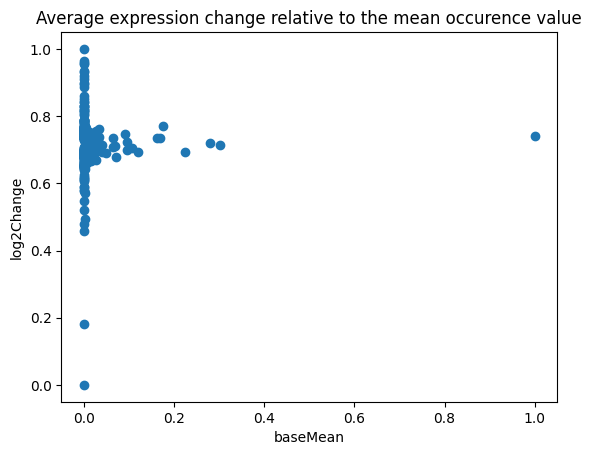

"\nX2=[]\ny2=[]\nfor items in comparison2.values():\n  X2.append(items[0])\n  y2.append(items[1])\nX2 = minMax(X2)\ny2 = minMax(y2)\nplt.scatter(X2, y2)\nplt.xlabel('baseMean')\nplt.ylabel('log2Change')\nplt.show()\n\nplt.scatter(X1, y1, label='Plastic', color='purple', marker='o')\nplt.scatter(X2, y2, label='Migraine', color='magenta', marker='o')\nplt.xlabel('baseMean')\nplt.ylabel('log2Change')\nplt.draw()\n\n\n\n\nfor key, items in comparison1.items():\n  val = comparison2[key]\n  nummin = min(items[0], val[0])\n  nummax = max(items[0], val[0])\n  logmin = min(abs(items[1]), abs(val[1]))\n  logmax = max(abs(items[1]), abs(val[1]))\n  #logmin = min(items[1], val[1])\n  #logmax = max(items[1], val[1])\n  if nummin/nummax >= 0.5 and logmin/logmax >= 0.67:\n    if items[1] < 0 and val[1] < 0 or items[1] > 0 and val[1] > 0:\n      print(key, items)\n      print(comparison2[key])\n      print(nummin/nummax)\n      print(logmin/logmax)\n \n  if nummin/nummax >= 0.8 and logmin/logmax >= 0.

In [ ]:
'''
def error_sorter(inputFile, alignFile):
  inputs = pd.read_csv(inputFile, index_col=0)
  statAlign = pd.read_csv(alignFile, index_col=0)
  input_index = list(inputs.index)
  align_index = list(statAlign.index)
  note = []
  for items in input_index:
    if items not in align_index:
      note.append(items)
  inputs = inputs.drop(index=note)
  inputs.to_csv(input('What name: '), index=True)
error_sorter('/content/stats_res200.csv', '/content/stat_migraine_filtered.csv')
'''
temp = {}
comparison1 = {}
comparison2 = {}
ped1 = pd.read_csv('/content/stats_res50Plastic.csv', index_col=0)
#ped2 = pd.read_csv('/content/test1.csv', index_col=0)
index1 = list(ped1.index)
#index2 = list(ped2.index)
print(len(index1))
#print(len(index2))
for items in index1:
  if items not in comparison1:
    comparison1[items] = [float(ped1.loc[items, 'baseMean']), float(ped1.loc[items, 'log2FoldChange'])]
    temp[items] = 1
'''
for items in index2:
  if items not in comparison2:
    comparison2[items] = [float(ped2.loc[items, 'baseMean']), float(ped2.loc[items, 'log2FoldChange'])]
    temp[items] = 1
    '''
print(len(comparison1))
#print(len(comparison2))
print(sorted(comparison1.items()))
#print(sorted(comparison2.items()))

from sklearn.preprocessing import MinMaxScaler

def minMax(input_array):
  scaler = MinMaxScaler()
  D2 =  np.array(input_array).reshape(-1,1)
  return scaler.fit_transform(D2).flatten().tolist()

X1=[]
y1=[]
for items in comparison1.values():
  X1.append(items[0])
  y1.append(items[1])
X1 = minMax(X1)
y1 = minMax(y1)
plt.scatter(X1, y1)
plt.xlabel('baseMean')
plt.ylabel('log2Change')
plt.title('Average expression change relative to the mean occurence value')
plt.show()
'''
X2=[]
y2=[]
for items in comparison2.values():
  X2.append(items[0])
  y2.append(items[1])
X2 = minMax(X2)
y2 = minMax(y2)
plt.scatter(X2, y2)
plt.xlabel('baseMean')
plt.ylabel('log2Change')
plt.show()

plt.scatter(X1, y1, label='Plastic', color='purple', marker='o')
plt.scatter(X2, y2, label='Migraine', color='magenta', marker='o')
plt.xlabel('baseMean')
plt.ylabel('log2Change')
plt.draw()




for key, items in comparison1.items():
  val = comparison2[key]
  nummin = min(items[0], val[0])
  nummax = max(items[0], val[0])
  logmin = min(abs(items[1]), abs(val[1]))
  logmax = max(abs(items[1]), abs(val[1]))
  #logmin = min(items[1], val[1])
  #logmax = max(items[1], val[1])
  if nummin/nummax >= 0.5 and logmin/logmax >= 0.67:
    if items[1] < 0 and val[1] < 0 or items[1] > 0 and val[1] > 0:
      print(key, items)
      print(comparison2[key])
      print(nummin/nummax)
      print(logmin/logmax)

  if nummin/nummax >= 0.8 and logmin/logmax >= 0.8:
    if items[1] < 0 and val[1] < 0 or items[1] > 0 and val[1] > 0:
      print(key, items)
      print(comparison2[key])
      print(nummin/nummax)
      print(logmin/logmax)
'''



  #else:
  #  temp[items + '1'] = [ped1.loc[]]
  #  temp[items] += 1
